# Chapter 5 — The Machine Learning Pipeline

**Goals**

- Run a full ML pipeline end-to-end on a real dataset.
- Load → split → baseline → scale → fit → evaluate, in that order.
- Implement the baseline two ways: from scratch (NumPy) and with `sklearn.dummy.DummyRegressor`.
- Implement a simple model two ways: from scratch (mean baseline + a hand-fitted linear model via gradient descent) and with `sklearn.linear_model.LinearRegression`.

Dataset: **California Housing** (downloaded by scikit-learn).

Pair with `docs/02_ml_concepts.md`.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

## 2. Load and inspect

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print('shape:', df.shape)
df.head()

shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Target is `MedHouseVal` (median house value in $100,000s). Features are 8 numeric columns describing each Californian census block group.

## 3. Split into train / validation / test

In [4]:
X = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED
)
print(f'train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}')

train: (13209, 8)  val: (3303, 8)  test: (4128, 8)


## 4. Baseline — predict the mean of the training target

### 4.1 From scratch

In [5]:
baseline_pred = np.full_like(y_val, fill_value=y_train.mean())
baseline_rmse = float(np.sqrt(mean_squared_error(y_val, baseline_pred)))
baseline_mae  = float(mean_absolute_error(y_val, baseline_pred))
print(f'Baseline mean prediction = {y_train.mean():.4f}')
print(f'Baseline RMSE = {baseline_rmse:.4f}')
print(f'Baseline MAE  = {baseline_mae:.4f}')

Baseline mean prediction = 2.0669
Baseline RMSE = 1.1750
Baseline MAE  = 0.9258


### 4.2 With scikit-learn

In [6]:
dummy = DummyRegressor(strategy='mean').fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
dummy_rmse = float(np.sqrt(mean_squared_error(y_val, dummy_pred)))
print(f'DummyRegressor RMSE = {dummy_rmse:.4f}  (matches the from-scratch baseline)')

DummyRegressor RMSE = 1.1750  (matches the from-scratch baseline)


## 5. Scale features

Fit the scaler on **train only**, then transform train / val / test. Doing this on the full dataset would leak information from the val/test sets into training (see §3.5 of the docs).

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print('train col means after scaling:', X_train_s.mean(axis=0).round(3))
print('train col stds  after scaling:', X_train_s.std(axis=0).round(3))

train col means after scaling: [-0. -0.  0. -0.  0.  0.  0. -0.]
train col stds  after scaling: [1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Train a linear regression — from scratch

We minimize the mean squared error via gradient descent. Reusing the gradient from Chapter 4:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{2}{N} \mathbf{X}^\top (\mathbf{X}\mathbf{w} - \mathbf{y})$$

From-scratch RMSE = 0.7344


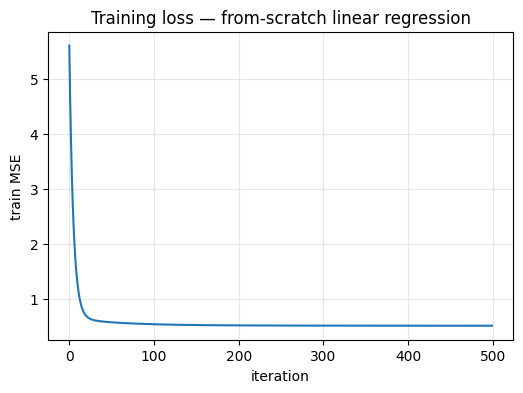

In [8]:
def fit_linear_gd(X, y, lr=0.05, n_iters=500):
    N, d = X.shape
    Xb = np.hstack([X, np.ones((N, 1))])             # append bias column of 1s
    w  = np.zeros(d + 1)
    history = []
    for _ in range(n_iters):
        err = Xb @ w - y
        grad = (2.0 / N) * (Xb.T @ err)
        w -= lr * grad
        history.append(np.mean(err ** 2))
    return w, np.array(history)

w_scratch, losses = fit_linear_gd(X_train_s, y_train, lr=0.05, n_iters=500)

X_val_b = np.hstack([X_val_s, np.ones((X_val_s.shape[0], 1))])
y_pred_scratch = X_val_b @ w_scratch
rmse_scratch = float(np.sqrt(mean_squared_error(y_val, y_pred_scratch)))
print(f'From-scratch RMSE = {rmse_scratch:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set_xlabel('iteration'); ax.set_ylabel('train MSE')
ax.set_title('Training loss — from-scratch linear regression')
ax.grid(True, alpha=0.3)
plt.show()

## 7. Train a linear regression — scikit-learn

In [9]:
lr = LinearRegression().fit(X_train_s, y_train)
y_pred_sk = lr.predict(X_val_s)
rmse_sk = float(np.sqrt(mean_squared_error(y_val, y_pred_sk)))
mae_sk  = float(mean_absolute_error(y_val, y_pred_sk))
r2_sk   = float(r2_score(y_val, y_pred_sk))
print(f'sklearn LinearRegression  RMSE = {rmse_sk:.4f}')
print(f'sklearn LinearRegression  MAE  = {mae_sk:.4f}')
print(f'sklearn LinearRegression  R^2  = {r2_sk:.4f}')

sklearn LinearRegression  RMSE = 0.7339
sklearn LinearRegression  MAE  = 0.5407
sklearn LinearRegression  R^2  = 0.6097


## 8. Compare baseline, from-scratch, and sklearn

In [10]:
summary = pd.DataFrame({
    'model':   ['baseline (mean)', 'linear regression (scratch GD)', 'linear regression (sklearn)'],
    'val_RMSE':[baseline_rmse,    rmse_scratch,                    rmse_sk],
})
summary

,model,val_RMSE
0,baseline (mean),1.174998
1,linear regression (scratch GD),0.734355
2,linear regression (sklearn),0.733898


The linear model massively beats the baseline. The from-scratch and sklearn versions agree to ~3 decimal places — they are solving the same problem.


## 9. Final test-set evaluation (do this once)

In [11]:
y_pred_test = lr.predict(X_test_s)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
mae_test  = float(mean_absolute_error(y_test, y_pred_test))
r2_test   = float(r2_score(y_test, y_pred_test))
print(f'TEST RMSE = {rmse_test:.4f}')
print(f'TEST MAE  = {mae_test:.4f}')
print(f'TEST R^2  = {r2_test:.4f}')

TEST RMSE = 0.7446
TEST MAE  = 0.5335
TEST R^2  = 0.5769


### Predicted vs actual

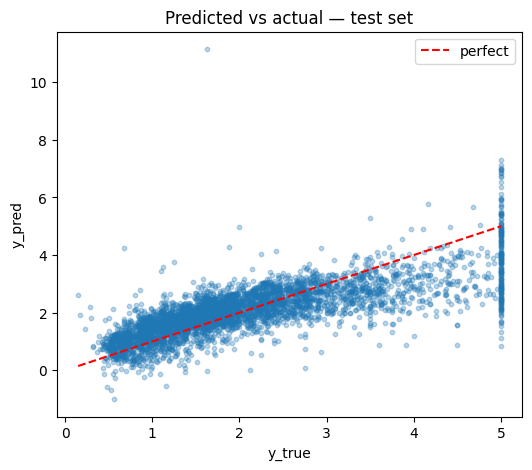

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='perfect')
ax.set_xlabel('y_true')
ax.set_ylabel('y_pred')
ax.set_title('Predicted vs actual — test set')
ax.legend()
plt.show()

## 10. Summary

- Always split train / val / test **before** any preprocessing.
- Always compute a baseline before training a real model.
- The scaler must be fit on train only.
- The from-scratch and the sklearn versions agree, confirming our gradient is correct.
- The test set is touched once, at the very end.

**Next:** dig deeper into splitting and leakage in `labs/lab_02_train_val_test_split.ipynb`.